# ✈️ 06. Pre-Departure Delay Prediction & Frontline Operations
### United Airlines Skyhack Operational Intelligence System

---

## 📌 Executive Summary
In this notebook, we implement **Upgrade #3 from the upgrade plan**: shifting the system from **post-flight descriptive analytics** (what happened after landing) to **pre-departure predictive forecasting** (what will happen before departure).

### Operational Constraints
- Feature space is **strictly limited to information available T-2 hours before scheduled departure**:
  - Booked passengers, load factor, basic economy ratio, child ratio
  - Total checked bags, booked transfer ratio, hot-transfer bags
  - Special Service Requests (Airport Wheelchairs, Unaccompanied Minors)
  - Scheduled ground turnaround time and required minimum turn buffer
  - Historical station departure and arrival delay congestion rates
- Objective ground truth target: **FAA Delay Standard** (departure or arrival delay $> 15$ minutes).
---


In [1]:
import sys
from pathlib import Path

# Add project root to path for robust imports across environments
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set publication-quality plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f"Environment initialized successfully. Project root: {root_dir}")


Environment initialized successfully. Project root: C:\Users\tusha\OneDrive\Desktop\Flight-Complexity-Analysis-and-Prediction


## 1. Pre-Departure Model Benchmark Results
Comparing XGBoost, Random Forest, LightGBM, and Logistic Regression on predicting delays before departure.


In [2]:
from src.config import REPORTS_DIR, MODELS_DIR

results_df = pd.read_csv(REPORTS_DIR / 'pre_departure_benchmark_results.csv')
results_df


,Model,CV_ROC_AUC,CV_F1,CV_Recall,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,XGBoost (Pre-Flight),0.6379,0.5751,0.5220,0.5877,0.5974,0.5877,0.5841,0.6429
1,Random Forest (Pre-Flight),0.6482,0.5461,0.4698,0.5883,0.6036,0.5883,0.5812,0.6406
2,LightGBM (Pre-Flight),0.6403,0.5902,0.5518,0.5981,0.6043,0.5981,0.5968,0.6339
3,Logistic Regression (Pre-Flight),0.5955,0.5542,0.5140,0.5698,0.5747,0.5698,0.5686,0.6089


## 2. Operational Threshold Tuning: Precision-Recall Trade-Off
In airline flight operations, missing a delayed/complex flight (False Negative) costs far more than a precautionary alert (False Positive). By tuning the decision threshold, station managers can calibrate alert sensitivity.


In [3]:
thresh_df = pd.read_csv(REPORTS_DIR / 'pre_departure_threshold_tuning.csv')
thresh_df


,Decision_Threshold,High_Risk_Precision,High_Risk_Recall,High_Risk_F1,Overall_Accuracy
0,0.3,0.5363,0.9587,0.6878,0.5451
1,0.4,0.5784,0.7969,0.6703,0.5901
2,0.5,0.6366,0.4923,0.5553,0.5877
3,0.6,0.7301,0.2810,0.4058,0.5698
4,0.7,0.8483,0.1783,0.2946,0.5537


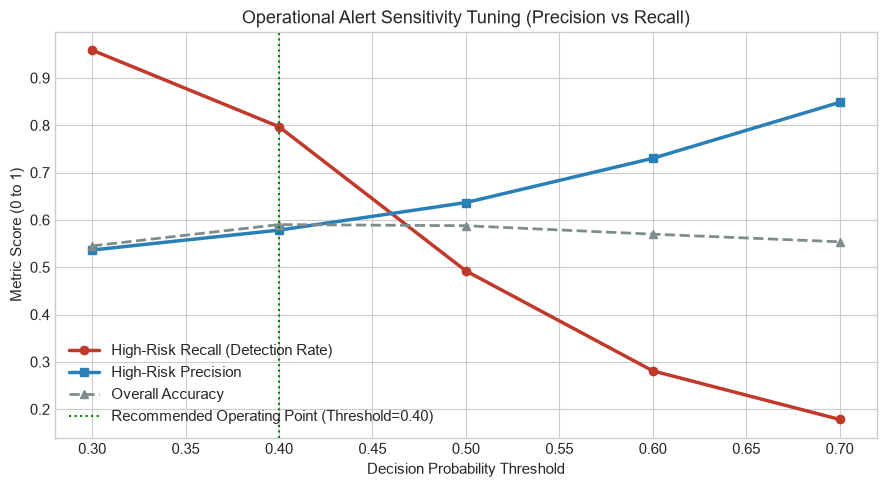

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['Decision_Threshold'], thresh_df['High_Risk_Recall'], marker='o', lw=2.5, label='High-Risk Recall (Detection Rate)', color='#C0392B')
ax.plot(thresh_df['Decision_Threshold'], thresh_df['High_Risk_Precision'], marker='s', lw=2.5, label='High-Risk Precision', color='#2980B9')
ax.plot(thresh_df['Decision_Threshold'], thresh_df['Overall_Accuracy'], marker='^', lw=2, linestyle='--', label='Overall Accuracy', color='#7F8C8D')

ax.axvline(0.40, color='green', linestyle=':', label='Recommended Operating Point (Threshold=0.40)')
ax.set_title('Operational Alert Sensitivity Tuning (Precision vs Recall)')
ax.set_xlabel('Decision Probability Threshold')
ax.set_ylabel('Metric Score (0 to 1)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Real-Time Pre-Departure Flight Simulation
Simulating pre-departure predictions and dispatcher tactical mitigation alerts:


In [5]:
from src.config import ENRICHED_COMPLEXITY_PATH
df = pd.read_csv(ENRICHED_COMPLEXITY_PATH)
pre_artifact = joblib.load(MODELS_DIR / 'pre_departure_model.joblib')
pipeline = pre_artifact['pipeline']
num_cols = pre_artifact['features']['numeric']
cat_cols = pre_artifact['features']['categorical']

# Sample 3 test flights
sample_flights = df.sample(3, random_state=123)
X_pre = sample_flights[num_cols + cat_cols].copy()
probs = pipeline.predict_proba(X_pre)[:, 1]

for i, (_, row) in enumerate(sample_flights.iterrows()):
    p = probs[i]
    print(f"\n--- Flight {row['company_id']} {row['flight_number']} ({row['route']}) ---")
    print(f"Scheduled Turn: {row['scheduled_ground_time_minutes']}m | Buffer: {row['buffer_minutes']}m | SSR Total: {row['ssr_total']}")
    print(f"Pre-Departure Delay Risk Probability: {p*100:.1f}%")
    if p >= 0.40:
        print("🚨 TACTICAL ALERT: High Operational Risk Detected!")
        print("   -> Deploy dedicated transfer baggage runner cart.")
        print("   -> Pre-position SSR wheelchair boarding assistants at gate.")
    else:
        print("✅ Nominal Operational Profile: Standard boarding and turnaround authorized.")



--- Flight UA 2862 (ORD→IAD) ---
Scheduled Turn: 67m | Buffer: 11m | SSR Total: 82
Pre-Departure Delay Risk Probability: 32.8%
✅ Nominal Operational Profile: Standard boarding and turnaround authorized.

--- Flight OO 4789 (ORD→FAR) ---
Scheduled Turn: 65m | Buffer: 31m | SSR Total: 33
Pre-Departure Delay Risk Probability: 29.1%
✅ Nominal Operational Profile: Standard boarding and turnaround authorized.

--- Flight OO 5526 (ORD→ATW) ---
Scheduled Turn: 55m | Buffer: 26m | SSR Total: 20
Pre-Departure Delay Risk Probability: 47.3%
🚨 TACTICAL ALERT: High Operational Risk Detected!
   -> Deploy dedicated transfer baggage runner cart.
   -> Pre-position SSR wheelchair boarding assistants at gate.


## 4. Frontline Operational Mitigation Playbook
When the pre-departure model alerts with probability $\ge 0.40$:
1. **Ramp Lead Assignment**: Assign senior ramp controller to oversee turnaround.
2. **Transfer Baggage Runner**: Pre-stage dedicated baggage tug for hot connections.
3. **SSR Escort Staging**: Position wheelchair gate assistants 15 minutes prior to boarding.
4. **Dispatcher ATC Coordination**: Secure priority pushback and taxiway clearance.
